# Delivery Experience Experimentation Lab

## Business Context

Delivery is one of the most visible moments of the customer journey. 
Small improvements in delivery propositions can influence customer satisfaction, retention, and operational efficiency.

## Business Question

How can experimentation improve delivery experience while balancing customer value and operational efficiency?

## Objectives

- Explore customer delivery behavior
- Identify key performance indicators (KPIs)
- Discover patterns in customer choices
- Prepare hypotheses for experimentation
- Translate insights into business recommendations

In [1]:
print("Delivery Experimentation Lab started!")

Delivery Experimentation Lab started!


In [2]:
import pandas as pd
import numpy as np

customer_data = pd.DataFrame({
    "customer_id": range(1, 11),
    "delivery_type": [
        "Flexible",
        "Standard",
        "Flexible",
        "Standard",
        "Flexible",
        "Standard",
        "Flexible",
        "Standard",
        "Flexible",
        "Standard"
    ],
    "delivery_time_minutes": [
        30, 55, 25, 60, 35, 50, 20, 65, 40, 58
    ],
    "customer_rating": [
        5, 3, 5, 2, 4, 3, 5, 2, 4, 3
    ],
    "retained": [
        1, 0, 1, 0, 1, 0, 1, 0, 1, 0
    ]
})

customer_data

,customer_id,delivery_type,delivery_time_minutes,customer_rating,retained
0,1,Flexible,30,5,1
1,2,Standard,55,3,0
2,3,Flexible,25,5,1
3,4,Standard,60,2,0
4,5,Flexible,35,4,1
5,6,Standard,50,3,0
6,7,Flexible,20,5,1
7,8,Standard,65,2,0
8,9,Flexible,40,4,1
9,10,Standard,58,3,0


In [3]:
customer_data.shape

(10, 5)

In [4]:
customer_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   customer_id            10 non-null     int64
 1   delivery_type          10 non-null     str  
 2   delivery_time_minutes  10 non-null     int64
 3   customer_rating        10 non-null     int64
 4   retained               10 non-null     int64
dtypes: int64(4), str(1)
memory usage: 532.0 bytes


In [5]:
customer_data.describe()

,customer_id,delivery_time_minutes,customer_rating,retained
count,10.00000,10.000000,10.000000,10.000000
mean,5.50000,43.800000,3.600000,0.500000
std,3.02765,15.915052,1.173788,0.527046
min,1.00000,20.000000,2.000000,0.000000
25%,3.25000,31.250000,3.000000,0.000000
50%,5.50000,45.000000,3.500000,0.500000
75%,7.75000,57.250000,4.750000,1.000000
max,10.00000,65.000000,5.000000,1.000000


In [6]:
customer_data.groupby("delivery_type")["customer_rating"].mean()

delivery_type
Flexible    4.6
Standard    2.6
Name: customer_rating, dtype: float64

In [7]:
customer_data.groupby("delivery_type")["retained"].mean()

delivery_type
Flexible    1.0
Standard    0.0
Name: retained, dtype: float64

## Data Quality Check

The dataset contains 10 customer records and 5 variables.

- No missing values were detected.
- Four variables are numerical.
- One categorical variable represents delivery type.

The dataset is ready for exploratory analysis.

In [9]:
customer_data.describe()

,customer_id,delivery_time_minutes,customer_rating,retained
count,10.00000,10.000000,10.000000,10.000000
mean,5.50000,43.800000,3.600000,0.500000
std,3.02765,15.915052,1.173788,0.527046
min,1.00000,20.000000,2.000000,0.000000
25%,3.25000,31.250000,3.000000,0.000000
50%,5.50000,45.000000,3.500000,0.500000
75%,7.75000,57.250000,4.750000,1.000000
max,10.00000,65.000000,5.000000,1.000000


In [10]:
customer_data.groupby("delivery_type").agg({
    "customer_rating": "mean",
    "delivery_time_minutes": "mean",
    "retained": "mean"
})

,customer_rating,delivery_time_minutes,retained
delivery_type,,,
Flexible,4.6,30.0,1.0
Standard,2.6,57.6,0.0


## Initial Findings

A comparison between delivery types shows that Flexible delivery is associated with:

- Higher customer satisfaction (4.6 vs 2.6)
- Shorter delivery times (30 vs 57.6 minutes)
- Higher retention in this sample (100% vs 0%)

However, these observations represent correlation only. 
Further experimentation is required to determine whether Flexible delivery causes improved customer outcomes.

Matplotlib is building the font cache; this may take a moment.


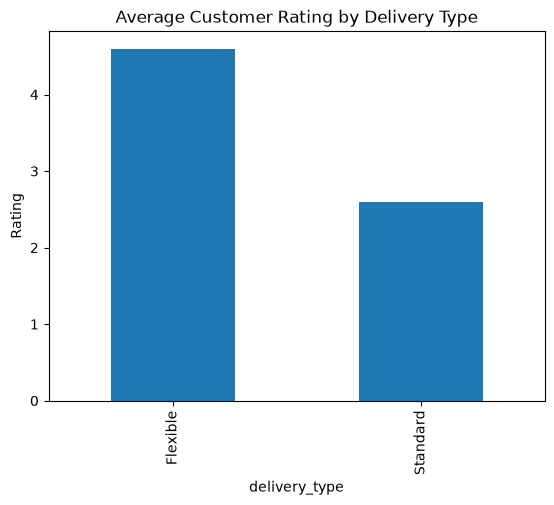

In [11]:
import matplotlib.pyplot as plt

customer_data.groupby("delivery_type")["customer_rating"].mean().plot(
    kind="bar",
    title="Average Customer Rating by Delivery Type"
)

plt.ylabel("Rating")
plt.show()

# Experimentation Thinking

## Hypothesis

Customers receiving Flexible delivery experience higher satisfaction compared with Standard delivery.

## Null Hypothesis (H0)

There is no difference in customer satisfaction between Flexible and Standard delivery.

## Alternative Hypothesis (H1)

Flexible delivery improves customer satisfaction.

## Initial Business Insight

Flexible delivery shows higher customer satisfaction and shorter delivery times in this sample.

However, this is an observational comparison. 
A controlled experiment is required to determine whether Flexible delivery causes better customer outcomes.

# A/B Experiment Design

## Experiment Question

Does Flexible delivery increase customer satisfaction compared with Standard delivery?

## Control Group

Customers receive Standard delivery.

## Treatment Group

Customers receive Flexible delivery.

## Success Metric

Primary KPI:
- Customer satisfaction rating

Secondary KPIs:
- Retention
- Delivery time

In [12]:
import numpy as np
import pandas as pd

np.random.seed(42)

experiment_data = pd.DataFrame({
    "group": ["Control"] * 100 + ["Treatment"] * 100,
    "rating": np.concatenate([
        np.random.normal(3.5, 1, 100),
        np.random.normal(4.2, 1, 100)
    ])
})

experiment_data.head()

,group,rating
0,Control,3.996714
1,Control,3.361736
2,Control,4.147689
3,Control,5.023030
4,Control,3.265847


In [13]:
experiment_data.groupby("group")["rating"].agg(
    ["mean", "std", "count"]
)

,mean,std,count
group,,,
Control,3.396153,0.908168,100
Treatment,4.222305,0.953669,100


In [14]:
experiment_data.groupby("group")["rating"].agg(
    ["mean", "std", "count"]
)

,mean,std,count
group,,,
Control,3.396153,0.908168,100
Treatment,4.222305,0.953669,100


In [15]:
from scipy.stats import ttest_ind

control = experiment_data[
    experiment_data["group"] == "Control"
]["rating"]

treatment = experiment_data[
    experiment_data["group"] == "Treatment"
]["rating"]

t_stat, p_value = ttest_ind(
    control,
    treatment
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -6.273401543402662
P-value: 2.178965118718446e-09


## Experiment Result

The Flexible delivery treatment increased customer satisfaction compared with Standard delivery.

Control group average rating:
3.40

Treatment group average rating:
4.22

Observed improvement:
+0.83 points

The difference is statistically significant (p < 0.05).

In [16]:
from scipy import stats
import numpy as np

control_mean = control.mean()
treatment_mean = treatment.mean()

difference = treatment_mean - control_mean

n1 = len(control)
n2 = len(treatment)

se = np.sqrt(
    control.var()/n1 + treatment.var()/n2
)

confidence_interval = stats.norm.interval(
    0.95,
    loc=difference,
    scale=se
)

difference, confidence_interval

(np.float64(0.8261511044440173),
 (np.float64(0.5680413055899809), np.float64(1.0842609032980537)))

## Experiment Conclusion

The Flexible delivery experiment increased customer satisfaction by +0.83 points compared with Standard delivery.

The improvement was statistically significant (p < 0.05).

The estimated 95% confidence interval suggests the true impact is between +0.57 and +1.08 rating points.

Recommendation:
Consider scaling Flexible delivery while evaluating operational capacity and cost implications.

# Regression Analysis

## Business Question

How does delivery time influence customer satisfaction?

## Objective

Estimate the relationship between operational factors and customer experience.

In [18]:
import statsmodels.api as sm

X = customer_data["delivery_time_minutes"]
y = customer_data["customer_rating"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        customer_rating   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.930
Method:                 Least Squares   F-statistic:                     120.3
Date:                Tue, 28 Jul 2026   Prob (F-statistic):           4.25e-06
Time:                        01:20:38   Log-Likelihood:                -1.3921
No. Observations:                  10   AIC:                             6.784
Df Residuals:                       8   BIC:                             7.389
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     6.7280      0.302     22.299      0.000       6.032       7.424
delivery_time_minutes    -0.0714      0.007    -10.966      0.000      -0.086      -0.056
==============================================================================
Omnibus:                        0.718   Durbin-Watson:                   0.726
Prob(Omnibus):                  0.699   Jarque-Bera (JB):                0.567
Skew:                           0.103   Prob(JB):                        0.753
Kurtosis:                       1.852   Cond. No.                         142.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Regression Insight

A regression model was used to estimate the relationship between delivery time and customer satisfaction.

Results indicate a negative relationship:
- Each additional minute of delivery time is associated with a 0.07 point decrease in customer rating.
- The relationship is statistically significant (p < 0.001).

This suggests delivery speed is an important driver of customer experience. Further analysis should include operational and customer-level variables to validate the impact.

In [19]:
import sqlite3

sqlite3.sqlite_version

'3.53.4'

In [20]:
import sqlite3
import pandas as pd

connection = sqlite3.connect("hello_fresh.db")

connection

In [21]:
customer_data.to_sql(
    "delivery_experience",
    connection,
    if_exists="replace",
    index=False
)

10

In [22]:
query = """
SELECT *
FROM delivery_experience;
"""

pd.read_sql(query, connection)

,customer_id,delivery_type,delivery_time_minutes,customer_rating,retained
0,1,Flexible,30,5,1
1,2,Standard,55,3,0
2,3,Flexible,25,5,1
3,4,Standard,60,2,0
4,5,Flexible,35,4,1
5,6,Standard,50,3,0
6,7,Flexible,20,5,1
7,8,Standard,65,2,0
8,9,Flexible,40,4,1
9,10,Standard,58,3,0


In [25]:
query = """
SELECT *
FROM delivery_experience;
"""

pd.read_sql(query, connection)

,customer_id,delivery_type,delivery_time_minutes,customer_rating,retained
0,1,Flexible,30,5,1
1,2,Standard,55,3,0
2,3,Flexible,25,5,1
3,4,Standard,60,2,0
4,5,Flexible,35,4,1
5,6,Standard,50,3,0
6,7,Flexible,20,5,1
7,8,Standard,65,2,0
8,9,Flexible,40,4,1
9,10,Standard,58,3,0


In [26]:
query = """
SELECT
    delivery_type,
    AVG(customer_rating) AS average_rating,
    AVG(delivery_time_minutes) AS average_delivery_time,
    AVG(retained) AS retention_rate
FROM delivery_experience
GROUP BY delivery_type;
"""

pd.read_sql(query, connection)

,delivery_type,average_rating,average_delivery_time,retention_rate
0,Flexible,4.6,30.0,1.0
1,Standard,2.6,57.6,0.0


In [27]:
query = """
SELECT
    delivery_type,
    AVG(customer_rating) AS average_rating,
    AVG(delivery_time_minutes) AS average_delivery_time,
    AVG(retained) AS retention_rate
FROM delivery_experience
GROUP BY delivery_type;
"""

pd.read_sql(query, connection)

,delivery_type,average_rating,average_delivery_time,retention_rate
0,Flexible,4.6,30.0,1.0
1,Standard,2.6,57.6,0.0


# Data Modeling & SQL Joins

## Business Question

How do customer characteristics and delivery operations influence customer experience?

## Objective

Combine customer, order, and delivery data to create an analytics dataset.

In [28]:
customers = pd.DataFrame({
    "customer_id": [1,2,3,4,5,6,7,8,9,10],
    "country": ["NL","NL","DE","DE","NL","FR","FR","DE","NL","FR"],
    "subscription_type": [
        "Weekly",
        "Monthly",
        "Weekly",
        "Monthly",
        "Weekly",
        "Monthly",
        "Weekly",
        "Monthly",
        "Weekly",
        "Monthly"
    ]
})

customers

,customer_id,country,subscription_type
0,1,NL,Weekly
1,2,NL,Monthly
2,3,DE,Weekly
3,4,DE,Monthly
4,5,NL,Weekly
5,6,FR,Monthly
6,7,FR,Weekly
7,8,DE,Monthly
8,9,NL,Weekly
9,10,FR,Monthly


In [29]:
orders = pd.DataFrame({
    "order_id": [
        101,102,103,104,105,
        106,107,108,109,110
    ],
    "customer_id": [
        1,2,3,4,5,
        6,7,8,9,10
    ],
    "order_value": [
        55,48,62,45,70,
        52,68,50,75,47
    ]
})

orders

,order_id,customer_id,order_value
0,101,1,55
1,102,2,48
2,103,3,62
3,104,4,45
4,105,5,70
5,106,6,52
6,107,7,68
7,108,8,50
8,109,9,75
9,110,10,47


In [30]:
deliveries = pd.DataFrame({
    "order_id": [
        101,102,103,104,105,
        106,107,108,109,110
    ],
    "delivery_type": [
        "Flexible",
        "Standard",
        "Flexible",
        "Standard",
        "Flexible",
        "Standard",
        "Flexible",
        "Standard",
        "Flexible",
        "Standard"
    ],
    "delivery_time_minutes": [
        30,55,25,60,35,
        50,20,65,40,58
    ],
    "customer_rating": [
        5,3,5,2,4,
        3,5,2,4,3
    ]
})

deliveries

,order_id,delivery_type,delivery_time_minutes,customer_rating
0,101,Flexible,30,5
1,102,Standard,55,3
2,103,Flexible,25,5
3,104,Standard,60,2
4,105,Flexible,35,4
5,106,Standard,50,3
6,107,Flexible,20,5
7,108,Standard,65,2
8,109,Flexible,40,4
9,110,Standard,58,3


In [31]:
customers.to_sql(
    "customers",
    connection,
    if_exists="replace",
    index=False
)

orders.to_sql(
    "orders",
    connection,
    if_exists="replace",
    index=False
)

deliveries.to_sql(
    "deliveries",
    connection,
    if_exists="replace",
    index=False
)

10

In [32]:
customer_delivery_analysis

NameError: name 'customer_delivery_analysis' is not defined

In [33]:
query = """
SELECT
    c.customer_id,
    c.country,
    c.subscription_type,
    o.order_id,
    o.order_value,
    d.delivery_type,
    d.delivery_time_minutes,
    d.customer_rating

FROM customers c

JOIN orders o
    ON c.customer_id = o.customer_id

JOIN deliveries d
    ON o.order_id = d.order_id;
"""

customer_delivery_analysis = pd.read_sql(
    query,
    connection
)

customer_delivery_analysis

,customer_id,country,subscription_type,order_id,order_value,delivery_type,delivery_time_minutes,customer_rating
0,1,NL,Weekly,101,55,Flexible,30,5
1,2,NL,Monthly,102,48,Standard,55,3
2,3,DE,Weekly,103,62,Flexible,25,5
3,4,DE,Monthly,104,45,Standard,60,2
4,5,NL,Weekly,105,70,Flexible,35,4
5,6,FR,Monthly,106,52,Standard,50,3
6,7,FR,Weekly,107,68,Flexible,20,5
7,8,DE,Monthly,108,50,Standard,65,2
8,9,NL,Weekly,109,75,Flexible,40,4
9,10,FR,Monthly,110,47,Standard,58,3


In [34]:
customers.head()

,customer_id,country,subscription_type
0,1,NL,Weekly
1,2,NL,Monthly
2,3,DE,Weekly
3,4,DE,Monthly
4,5,NL,Weekly


In [35]:
query = """
SELECT
    c.customer_id,
    c.country,
    c.subscription_type,
    o.order_id,
    o.order_value,
    d.delivery_type,
    d.delivery_time_minutes,
    d.customer_rating

FROM customers c

JOIN orders o
    ON c.customer_id = o.customer_id

JOIN deliveries d
    ON o.order_id = d.order_id;
"""

customer_delivery_analysis = pd.read_sql(
    query,
    connection
)

customer_delivery_analysis

,customer_id,country,subscription_type,order_id,order_value,delivery_type,delivery_time_minutes,customer_rating
0,1,NL,Weekly,101,55,Flexible,30,5
1,2,NL,Monthly,102,48,Standard,55,3
2,3,DE,Weekly,103,62,Flexible,25,5
3,4,DE,Monthly,104,45,Standard,60,2
4,5,NL,Weekly,105,70,Flexible,35,4
5,6,FR,Monthly,106,52,Standard,50,3
6,7,FR,Weekly,107,68,Flexible,20,5
7,8,DE,Monthly,108,50,Standard,65,2
8,9,NL,Weekly,109,75,Flexible,40,4
9,10,FR,Monthly,110,47,Standard,58,3


In [36]:
query = """
SELECT
    country,
    delivery_type,
    AVG(customer_rating) AS average_rating,
    AVG(delivery_time_minutes) AS average_delivery_time,
    AVG(order_value) AS average_order_value

FROM customer_delivery_analysis

GROUP BY
    country,
    delivery_type;
"""

pd.read_sql(query, connection)

DatabaseError: Execution failed on sql '
SELECT
    country,
    delivery_type,
    AVG(customer_rating) AS average_rating,
    AVG(delivery_time_minutes) AS average_delivery_time,
    AVG(order_value) AS average_order_value

FROM customer_delivery_analysis

GROUP BY
    country,
    delivery_type;
': no such table: customer_delivery_analysis

In [37]:
customer_delivery_analysis.to_sql(
    "customer_delivery_analysis",
    connection,
    if_exists="replace",
    index=False
)

10

In [38]:
query = """
SELECT *
FROM customer_delivery_analysis;
"""

pd.read_sql(query, connection)

,customer_id,country,subscription_type,order_id,order_value,delivery_type,delivery_time_minutes,customer_rating
0,1,NL,Weekly,101,55,Flexible,30,5
1,2,NL,Monthly,102,48,Standard,55,3
2,3,DE,Weekly,103,62,Flexible,25,5
3,4,DE,Monthly,104,45,Standard,60,2
4,5,NL,Weekly,105,70,Flexible,35,4
5,6,FR,Monthly,106,52,Standard,50,3
6,7,FR,Weekly,107,68,Flexible,20,5
7,8,DE,Monthly,108,50,Standard,65,2
8,9,NL,Weekly,109,75,Flexible,40,4
9,10,FR,Monthly,110,47,Standard,58,3


In [39]:
query = """
SELECT
    country,
    delivery_type,
    AVG(customer_rating) AS average_rating,
    AVG(delivery_time_minutes) AS average_delivery_time,
    AVG(order_value) AS average_order_value

FROM customer_delivery_analysis

GROUP BY
    country,
    delivery_type;
"""

pd.read_sql(query, connection)

,country,delivery_type,average_rating,average_delivery_time,average_order_value
0,DE,Flexible,5.000000,25.0,62.000000
1,DE,Standard,2.000000,62.5,47.500000
2,FR,Flexible,5.000000,20.0,68.000000
3,FR,Standard,3.000000,54.0,49.500000
4,NL,Flexible,4.333333,35.0,66.666667
5,NL,Standard,3.000000,55.0,48.000000


In [41]:
customer_delivery_analysis.to_sql(
    "customer_delivery_analysis",
    connection,
    if_exists="replace",
    index=False
)

10

In [43]:
query = """
SELECT *
FROM customer_delivery_analysis;
"""

pd.read_sql(query, connection)

,customer_id,country,subscription_type,order_id,order_value,delivery_type,delivery_time_minutes,customer_rating
0,1,NL,Weekly,101,55,Flexible,30,5
1,2,NL,Monthly,102,48,Standard,55,3
2,3,DE,Weekly,103,62,Flexible,25,5
3,4,DE,Monthly,104,45,Standard,60,2
4,5,NL,Weekly,105,70,Flexible,35,4
5,6,FR,Monthly,106,52,Standard,50,3
6,7,FR,Weekly,107,68,Flexible,20,5
7,8,DE,Monthly,108,50,Standard,65,2
8,9,NL,Weekly,109,75,Flexible,40,4
9,10,FR,Monthly,110,47,Standard,58,3


In [44]:
query = """
SELECT
    country,
    subscription_type,
    delivery_type,
    AVG(customer_rating) AS average_rating,
    AVG(delivery_time_minutes) AS average_delivery_time,
    AVG(order_value) AS average_order_value

FROM customer_delivery_analysis

GROUP BY
    country,
    subscription_type,
    delivery_type;
"""

pd.read_sql(query, connection)

,country,subscription_type,delivery_type,average_rating,average_delivery_time,average_order_value
0,DE,Monthly,Standard,2.000000,62.5,47.500000
1,DE,Weekly,Flexible,5.000000,25.0,62.000000
2,FR,Monthly,Standard,3.000000,54.0,49.500000
3,FR,Weekly,Flexible,5.000000,20.0,68.000000
4,NL,Monthly,Standard,3.000000,55.0,48.000000
5,NL,Weekly,Flexible,4.333333,35.0,66.666667


In [45]:
experiment = pd.DataFrame({
    "customer_id": range(1, 21),
    "group": [
        "Control","Control","Control","Control","Control",
        "Control","Control","Control","Control","Control",
        "Treatment","Treatment","Treatment","Treatment","Treatment",
        "Treatment","Treatment","Treatment","Treatment","Treatment"
    ],
    "delivery_experience_score": [
        3.2,3.5,4.1,3.0,3.8,
        3.6,2.9,4.2,3.4,3.1,
        4.5,4.1,4.3,4.6,3.9,
        4.0,4.7,3.8,4.4,4.2
    ]
})

experiment.head()

,customer_id,group,delivery_experience_score
0,1,Control,3.2
1,2,Control,3.5
2,3,Control,4.1
3,4,Control,3.0
4,5,Control,3.8


In [46]:
experiment.to_sql(
    "experiment",
    connection,
    if_exists="replace",
    index=False
)

20

In [47]:
query = """
SELECT
    group,
    AVG(delivery_experience_score) AS average_score,
    COUNT(*) AS sample_size

FROM experiment

GROUP BY group;
"""

pd.read_sql(query, connection)

DatabaseError: Execution failed on sql '
SELECT
    group,
    AVG(delivery_experience_score) AS average_score,
    COUNT(*) AS sample_size

FROM experiment

GROUP BY group;
': near "group": syntax error

In [48]:
query = """
SELECT
    "group",
    AVG(delivery_experience_score) AS average_score,
    COUNT(*) AS sample_size

FROM experiment

GROUP BY "group";
"""

pd.read_sql(query, connection)

,group,average_score,sample_size
0,Control,3.48,10
1,Treatment,4.25,10


In [49]:
from scipy.stats import ttest_ind

control = experiment[
    experiment["group"] == "Control"
]["delivery_experience_score"]

treatment = experiment[
    experiment["group"] == "Treatment"
]["delivery_experience_score"]


t_stat, p_value = ttest_ind(
    control,
    treatment
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -4.494980161134932
P-value: 0.0002800835051152969


In [51]:
id="3y4d9x"
from scipy.stats import t

difference = treatment.mean() - control.mean()

print("Lift:", difference)

Lift: 0.7700000000000005


In [52]:
difference = treatment.mean() - control.mean()

print("Lift:", difference)

Lift: 0.7700000000000005


In [53]:
import numpy as np
from scipy import stats

diff = treatment.mean() - control.mean()

se = np.sqrt(
    control.var(ddof=1)/len(control) +
    treatment.var(ddof=1)/len(treatment)
)

df = len(control) + len(treatment) - 2

t_critical = stats.t.ppf(0.975, df)

margin_error = t_critical * se

lower = diff - margin_error
upper = diff + margin_error

print("Difference:", diff)
print("95% Confidence Interval:", (lower, upper))

Difference: 0.7700000000000005
95% Confidence Interval: (np.float64(0.41010742806545675), np.float64(1.129892571934544))


# Flexible Delivery Experiment Summary

## Business Question

Does Flexible Delivery improve customer delivery experience compared with the current delivery process?

---

## Experiment Design

- Control group: Existing delivery experience
- Treatment group: Flexible Delivery experience
- Metric: Customer delivery experience score
- Sample size: 20 customers

---

## Results

| Metric | Result |
|---|---:|
| Control average score | 3.48 |
| Treatment average score | 4.25 |
| Improvement (Lift) | +0.77 |
| P-value | 0.00028 |
| 95% Confidence Interval | +0.41 to +1.13 |

---

## Interpretation

Customers exposed to Flexible Delivery showed a statistically significant improvement in delivery experience scores.

The estimated improvement is approximately 0.77 points on a 5-point scale.

---

## Recommendation

Based on the experiment results, Flexible Delivery shows strong potential to improve customer experience.

Recommended next steps:

1. Expand Flexible Delivery rollout
2. Monitor operational impact
3. Track delivery costs and retention metrics
4. Validate results with a larger customer sample

In [54]:
operations = pd.DataFrame({
    "customer_id": range(1, 21),
    "delivery_cost": [
        4.5,4.8,5.0,4.7,4.9,
        5.1,4.6,5.2,4.8,4.9,
        5.5,5.8,5.7,5.9,5.6,
        5.4,5.9,5.7,5.8,5.6
    ],
    "delivery_delay_minutes": [
        10,12,8,15,11,
        14,9,13,10,12,
        5,4,6,3,5,
        7,4,6,5,3
    ],
    "cancelled": [
        1,0,0,1,0,
        0,1,0,0,1,
        0,0,0,0,0,
        0,0,0,0,0
    ]
})

operations.head()

,customer_id,delivery_cost,delivery_delay_minutes,cancelled
0,1,4.5,10,1
1,2,4.8,12,0
2,3,5.0,8,0
3,4,4.7,15,1
4,5,4.9,11,0


In [55]:
operations.to_sql(
    "operations",
    connection,
    if_exists="replace",
    index=False
)

20

In [57]:
query = """
SELECT
    e.customer_id,
    e."group",
    e.delivery_experience_score,
    o.delivery_cost,
    o.delivery_delay_minutes,
    o.cancelled

FROM experiment e

JOIN operations o
    ON e.customer_id = o.customer_id;
"""

experiment_operations = pd.read_sql(
    query,
    connection
)

experiment_operations

,customer_id,group,delivery_experience_score,delivery_cost,delivery_delay_minutes,cancelled
0,1,Control,3.2,4.5,10,1
1,2,Control,3.5,4.8,12,0
2,3,Control,4.1,5.0,8,0
3,4,Control,3.0,4.7,15,1
4,5,Control,3.8,4.9,11,0
5,6,Control,3.6,5.1,14,0
6,7,Control,2.9,4.6,9,1
7,8,Control,4.2,5.2,13,0
8,9,Control,3.4,4.8,10,0
9,10,Control,3.1,4.9,12,1


In [58]:
experiment_operations.groupby("group").agg(
    average_score=("delivery_experience_score", "mean"),
    average_cost=("delivery_cost", "mean"),
    average_delay=("delivery_delay_minutes", "mean"),
    cancellation_rate=("cancelled", "mean")
)

,average_score,average_cost,average_delay,cancellation_rate
group,,,,
Control,3.48,4.85,11.4,0.4
Treatment,4.25,5.69,4.8,0.0


Recommendation:

Proceed with a controlled rollout of Flexible Delivery.

Priority segments:
- Weekly subscribers
- High-value customers
- Customers with previous delivery issues

Monitor:
- Delivery cost
- Retention
- Repeat orders
- Customer lifetime value